# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
   
   It helps control model complexity by imposing a higher cost on larger coefficients. This forces the model to choose more predictive variables with smaller coefficientsl, reducing model variance.

2. How does regularization provide a way of exploring the bias-variance trade-off?
   
   More complex models have lower bias but higher variance. Regularization provides a way of reducing variance by limiting variables to only the most predictive ones, but in doing so, increases the bias as less information is being included in the prediction.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
   
   LASSO performs automatic feature selection by reducing coefficients to 0, while Ridge regression never removes a variable completely, instead reducing coefficients asymptotically to 0.

4. How do we typically scale variables for use in regularized regression? Why?
   
   Z-score normalize numeric variables. Because the cost function compares variables indirectly by determining their predictive power, it is more sensitive to changing variable scales that could artificially boost comparisons.

5. How is the penalty $\alpha$ typically selected?
   
   Cross validate each $\alpha$ from a grid of $\alpha$ values, calculating the mean/median MSE. Then choose the $\alpha$ with the lowest MSE.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
   
   No. The penalty term affects how the model is fit, not how the model evaluates unseen data, which cross validation is meant to measure. It depends on the model parameters, not the features themselves.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
   
   Negative

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
   
   At optimal $\alpha$, all features were selected except for Age $^2$, which was set to 0.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?
   
   None of the coefficients increased in magnitude. The coefficient for Age $^3$ changed signs.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
df_cars = pd.read_csv("data/cars_hw.csv")
df_cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [4]:
df_cars["Age"] = datetime.now().year - df_cars["Make_Year"]
df_cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [47]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

y = df_cars["Price"]
X = df_cars.loc[:, ["Mileage_Run", "Age"]]

expander = PolynomialFeatures(degree=3, include_bias=False)
X_poly = expander.fit_transform(X)
poly_names = expander.get_feature_names_out()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [48]:
from sklearn.linear_model import LinearRegression

model_linear = LinearRegression()
model_linear = model_linear.fit(X_scaled, y)

pd.DataFrame({"variable":poly_names, "coefficient":model_linear.coef_})

,variable,coefficient
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05


/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the feature

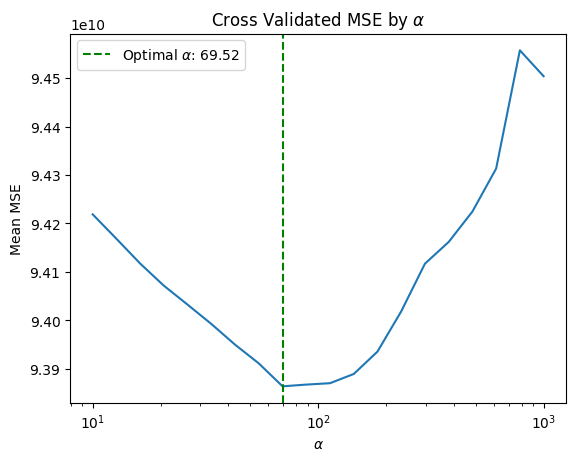

In [57]:
from sklearn.linear_model import LassoCV, Lasso

alpha_grid = np.logspace(1, 3, 20)
model_lasso = LassoCV(cv=20, alphas=alpha_grid, random_state=100)
model_lasso = model_lasso.fit(X_scaled, y)

optimal_alpha = model_lasso.alpha_
sns.lineplot(x=model_lasso.alphas_, y=np.mean(model_lasso.mse_path_, axis=1))
plt.axvline(x=optimal_alpha, color="green", linestyle="--", label=rf"Optimal $\alpha$: {optimal_alpha:.2f}")
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Mean MSE")
plt.title(r"Cross Validated MSE by $\alpha$")
plt.legend()
plt.show()

/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consi

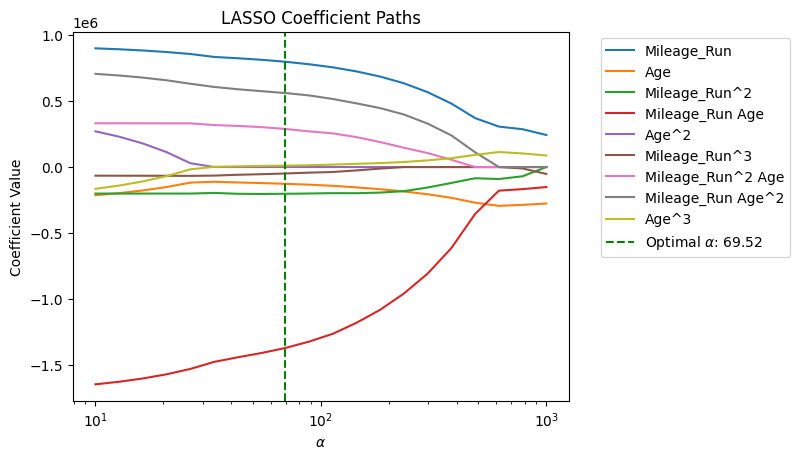

In [58]:
coefs = []
for alpha in alpha_grid:
    model = Lasso(alpha=alpha, max_iter=10000)
    model = model.fit(X_scaled, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=poly_names[i])

plt.axvline(x=optimal_alpha, color="green", linestyle="--", label=rf"Optimal $\alpha$: {optimal_alpha:.2f}")
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [59]:
model_optimal = Lasso(alpha=optimal_alpha, max_iter=10000)
model_optimal.fit(X_scaled, y)

pd.DataFrame({"variable":poly_names, "linear coefficient":model_linear.coef_, "optimal coefficient":model_optimal.coef_, 
              "change in magnitude":abs(model_optimal.coef_) - abs(model_linear.coef_)})

/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.529e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(


,variable,linear coefficient,optimal coefficient,change in magnitude
0,Mileage_Run,9.117748e+05,7.978919e+05,-113882.956248
1,Age,-2.481722e+05,-1.270107e+05,-121161.476719
2,Mileage_Run^2,-2.072926e+05,-2.026748e+05,-4617.794104
3,Mileage_Run Age,-1.671212e+06,-1.371347e+06,-299864.916842
4,Age^2,3.505507e+05,0.000000e+00,-350550.719877
5,Mileage_Run^3,-6.514490e+04,-4.898892e+04,-16155.978842
6,Mileage_Run^2 Age,3.388195e+05,2.884440e+05,-50375.410987
7,Mileage_Run Age^2,7.167816e+05,5.607301e+05,-156051.450144
8,Age^3,-2.100379e+05,1.049869e+04,-199539.201688


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
   
   The coefficients for the categorical variables seem to indicate that the chance of a `DEATH_EVENT` decreases if they are true, which is counterintuitive. However, when looking at the positive coefficients of the interaction terms, these variables correspond to much higher risk for a `DEATH_EVENT`.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.
   
   At optimal $\alpha$, the features selected are `ejection_fraction`, `serum_creatinine`, `age`$^3$, `ejection_fraction`$^3$, `ejection_fraction`$^2$ x `serum_creatinine`, `serum_creatinine`$^3$, `anaemia`, `diabetes`, `high_blood_pressure`, `diabetes` x `high_blood_pressure`, `diabetes` x `smoking`, and `high_blood_pressure` x `smoking`. 21/33 = 64% of features were set to 0.

   Only the coefficient of `serum_creatinine`$^3$ increased in magnitude. The coefficients of `serum_creatinine`, `ejection_fraction`$^3$, `ejection_fraction`$^2$ x `serum_creatinine`, `anaemia`, `diabetes`, and `high_blood_pressure` flipped signs.
   
   The sign patterns of the LASSO model make more sense. Here, the categorical variables now have positive coefficients, indicating that the chance of a `DEATH_EVENT` increases when they are present. Additionally, `age` has been exluded from the model while `age`$^3$ is included, indicating that the chance of a `DEATH_EVENT` is not linear with age, and how much it increases varies at different ages. The LASSO model exchanges an increase in bias for a decrease in variance, producing a more interpretable model with the most predictive features.

In [10]:
df_heart = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")
df_heart.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [60]:
y = df_heart["DEATH_EVENT"]

X_num = df_heart[["age", "ejection_fraction", "serum_creatinine"]]
expander = PolynomialFeatures(degree=3, include_bias=False)
X_num_poly = expander.fit_transform(X_num)
num_poly_names = expander.get_feature_names_out()

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_poly)

X_cat = df_heart[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]
expander_cat = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_cat_poly = expander_cat.fit_transform(X_cat)
cat_poly_names = expander_cat.get_feature_names_out()

feature_names = np.concat([num_poly_names, cat_poly_names])
X_full = np.concat([X_num_scaled, X_cat_poly], axis=1)

In [74]:
model_linear = LinearRegression()
model_linear = model_linear.fit(X_full, y)

pd.DataFrame({"variable":feature_names, "coefficient":model_linear.coef_})

,variable,coefficient
0,age,1.549928
1,ejection_fraction,-2.025371
2,serum_creatinine,-0.739027
3,age^2,-3.547991
4,age ejection_fraction,-0.861860
5,age serum_creatinine,1.680570
6,ejection_fraction^2,3.317931
7,ejection_fraction serum_creatinine,2.604767
8,serum_creatinine^2,-2.703084
9,age^3,1.889040


/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.010e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.382e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the feature

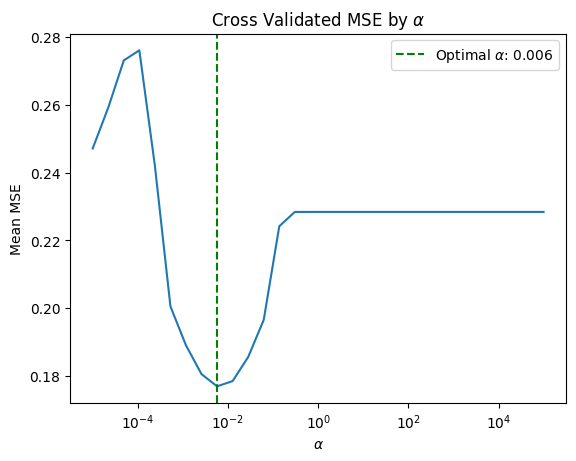

In [62]:
alphas = np.logspace(-5, 5, 30)
model_lasso = LassoCV(cv=20, alphas=alphas, random_state=100)
model_lasso = model_lasso.fit(X_full, y)

optimal_alpha = model_lasso.alpha_
sns.lineplot(x=model_lasso.alphas_, y=np.mean(model_lasso.mse_path_, axis=1))
plt.axvline(x=optimal_alpha, color="green", linestyle="--", label=rf"Optimal $\alpha$: {optimal_alpha:.3f}")
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Mean MSE")
plt.title(r"Cross Validated MSE by $\alpha$")
plt.legend()
plt.show()

/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.349e-01, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.218e-02, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/asong/anaconda3/envs/DS3001/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the feature

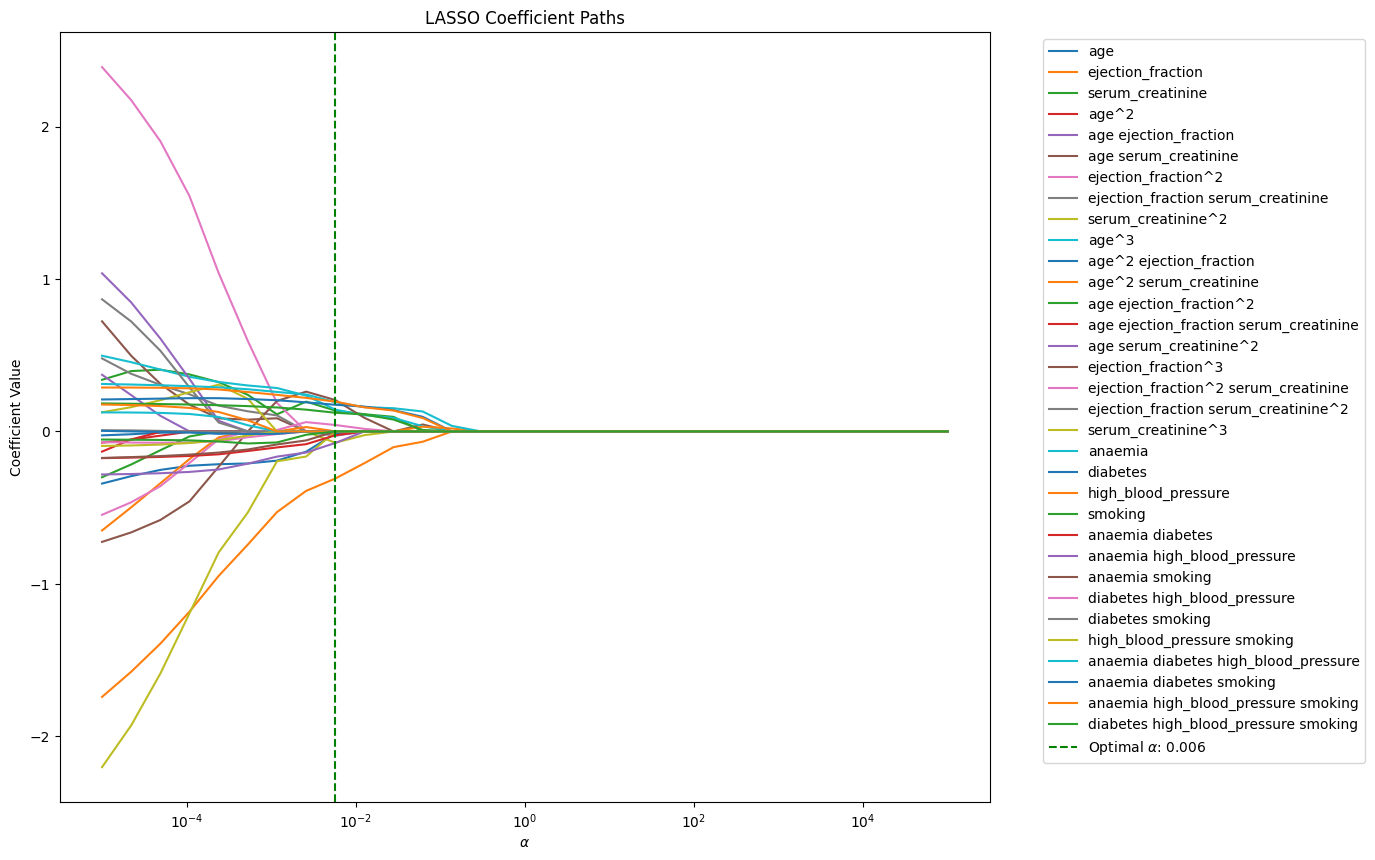

In [70]:
from sklearn.linear_model import lasso_path

alphas_lasso, coefs, _ = lasso_path(X_full, y, alphas=alphas)

plt.figure(figsize=(12, 10))
for i in range(coefs.shape[0]):
    plt.plot(alphas_lasso, coefs[i], label=feature_names[i])

plt.axvline(x=optimal_alpha, color="green", linestyle="--", label=rf"Optimal $\alpha$: {optimal_alpha:.3f}")
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [75]:
model_optimal = Lasso(alpha=optimal_alpha, max_iter=10000)
model_optimal.fit(X_full, y)

pd.DataFrame({"variable":feature_names, "linear coefficient":model_linear.coef_, "optimal coefficient":model_optimal.coef_, 
              "change in magnitude":abs(model_optimal.coef_) - abs(model_linear.coef_)})

,variable,linear coefficient,optimal coefficient,change in magnitude
0,age,1.549928,-0.000000,-1.549928
1,ejection_fraction,-2.025371,-0.329656,-1.695715
2,serum_creatinine,-0.739027,0.116875,-0.622151
3,age^2,-3.547991,0.000000,-3.547991
4,age ejection_fraction,-0.861860,-0.000000,-0.861860
5,age serum_creatinine,1.680570,0.000000,-1.680570
6,ejection_fraction^2,3.317931,0.000000,-3.317931
7,ejection_fraction serum_creatinine,2.604767,0.000000,-2.604767
8,serum_creatinine^2,-2.703084,-0.000000,-2.703084
9,age^3,1.889040,0.117992,-1.771049


**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
   
   $b_0 = 0$ since $x$ and $y$ are mean-normalized.
   
   $$\text{objective function } J = \text{MSE} + \text{penalty} = \frac{1}{n} \sum_{i=1}^{n} \left(\tilde{y}_i - b_1 \tilde{x}_i \right)^2 + \alpha (b_1)^2$$

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
   
   $$\frac{\partial J}{\partial b_1} = -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) + 2\alpha b_i$$
   $$-\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) + 2\alpha b_i = 0$$
   $$-\frac{1}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i + \frac{1}{n} \sum_{i=1}^n \tilde{x}_i^2 b_1 + \alpha b_i = 0$$
   $$b_1(\frac{1}{n} \sum_{i=1}^n \tilde{x}_i^2 + \alpha) = \frac{1}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i$$
   $$b_1 = \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i}{\sum_{i=1}^n \tilde{x}_i^2 + n\alpha}$$
   $b_0 = 0$ since $x$ and $y$ are mean-normalized.

1. How does increasing $\alpha$ change the slope coefficient?
   
   Since $\alpha$ is in the denominator, increasing $\alpha$ (the penalty) decreases the slope coefficient towards 0.

2. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?
   
   The derivative of the absolute value is undefined for $b_1 = 0$.

   Case 1: if $b_1 > 0$

   $$\text{objective function } J = \text{MSE} + \text{penalty} = \frac{1}{n} \sum_{i=1}^{n} \left(\tilde{y}_i - b_1 \tilde{x}_i \right)^2 + \alpha b_1$$
   $$\frac{\partial J}{\partial b_1} = -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) + \alpha$$
   $$-\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) + \alpha = 0$$
   $$-\frac{2}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i + \frac{2}{n} \sum_{i=1}^n \tilde{x}_i^2 b_1 + \alpha = 0$$
   $$b_1(\frac{2}{n} \sum_{i=1}^n \tilde{x}_i^2) = \frac{2}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i - \alpha$$
   $$b_1 = \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i - \frac{n\alpha}{2}}{\sum_{i=1}^n \tilde{x}_i^2}$$

   Since we assume $b_1$ is positive, it must be true that
   $$\sum_{i=1}^n \tilde{x}_i \tilde{y}_i > \frac{n\alpha}{2}$$

   Case 2: if $b_1 < 0$

   $$\text{objective function } J = \text{MSE} + \text{penalty} = \frac{1}{n} \sum_{i=1}^{n} \left(\tilde{y}_i - b_1 \tilde{x}_i \right)^2 - \alpha b_1$$
   $$\frac{\partial J}{\partial b_1} = -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) - \alpha$$
   $$-\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) - \alpha = 0$$
   $$b_1 = \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i + \frac{n\alpha}{2}}{\sum_{i=1}^n \tilde{x}_i^2}$$

   Since we assume $b_1$ is negative, it must be true that
   $$\sum_{i=1}^n \tilde{x}_i \tilde{y}_i < -\frac{n\alpha}{2}$$

   Case 3: if $b_1 = 0$
   
   The region
   $$-\frac{n\alpha}{2} \leq \sum_{i=1}^n \tilde{x}_i \tilde{y}_i \leq \frac{n\alpha}{2}$$
   $$|\sum_{i=1}^n \tilde{x}_i \tilde{y}_i| \leq \frac{n\alpha}{2}$$
   therefore corresponds to $b_1 = 0$.

   Thus,

   $$b_1 = \left\{\begin{matrix} \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i - \frac{n\alpha}{2}}{\sum_{i=1}^n \tilde{x}_i^2} & \sum_{i=1}^n \tilde{x}_i \tilde{y}_i > \frac{n\alpha}{2} \\ 0 & |\sum_{i=1}^n \tilde{x}_i \tilde{y}_i| \leq \frac{n\alpha}{2} \\ \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i + \frac{n\alpha}{2}}{\sum_{i=1}^n \tilde{x}_i^2} & \sum_{i=1}^n \tilde{x}_i \tilde{y}_i < -\frac{n\alpha}{2} \\ \end{matrix}\right.$$